# Objetivo 4 — Evaluación y segregación de riesgo

⚠️ **Privacidad:** las salidas se eliminaron porque los datos contienen información de estudiantes menores. Ejecute este cuaderno solo en un entorno institucional autorizado y no publique tablas con nombres, RUDE o fechas de nacimiento.


Este cuaderno compara los tres clasificadores. La regla pedagógica del prototipo es una salida operativa separada de estas métricas.

La fuente canónica es `scripts/train_models.py`: construye transiciones T→T+1, entrena con 2022→2023 y prueba con 2023→2024. Solo existen seis transiciones positivas, por lo que los resultados son exploratorios.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
METRICS_PATH = ROOT / 'resultados_modelos' / 'metricas_modelos.json'

# Ejecute `python scripts/train_models.py` desde la raíz para reconstruir modelos y métricas.
with METRICS_PATH.open(encoding='utf-8') as stream:
    resultados = json.load(stream)

print('Entrenamiento:', resultados['entrenamiento_temporal'])
print('Prueba:', resultados['prueba_temporal'])
print('Variables:', resultados['variables_predictoras'])


Entrenamiento: {'transicion': '2022->2023', 'n': 241, 'positivos': 3}
Prueba: {'transicion': '2023->2024', 'n': 248, 'positivos': 3}
Variables: ['promedio_general_prev', 'num_materias_reprobadas_prev']


In [2]:
filas = []
for nombre in ['decision_tree', 'random_forest', 'mlp']:
    m = resultados['evaluacion'][nombre]
    filas.append({
        'modelo': nombre,
        'matriz_confusion': m['confusion_matrix'],
        'precision_rezago': m['precision_rezago'],
        'recall_rezago': m['recall_rezago'],
        'f1_rezago': m['f1_rezago'],
        'balanced_accuracy': m['balanced_accuracy'],
        'average_precision': m['average_precision'],
    })
tabla_metricas = pd.DataFrame(filas)
tabla_metricas


,modelo,matriz_confusion,precision_rezago,recall_rezago,f1_rezago,balanced_accuracy,average_precision
0,decision_tree,"[[232, 13], [2, 1]]",0.071429,0.333333,0.117647,0.640136,0.031874
1,random_forest,"[[232, 13], [2, 1]]",0.071429,0.333333,0.117647,0.640136,0.063620
2,mlp,"[[245, 0], [3, 0]]",0.000000,0.000000,0.000000,0.500000,0.233154


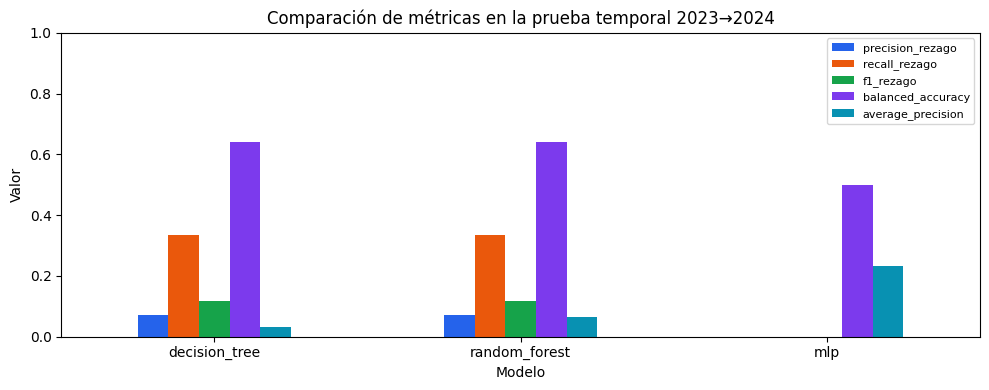

In [3]:
metricas_plot = tabla_metricas.set_index('modelo')[
    ['precision_rezago', 'recall_rezago', 'f1_rezago', 'balanced_accuracy', 'average_precision']
]
ax = metricas_plot.plot(kind='bar', figsize=(10, 4), ylim=(0, 1), color=['#2563eb', '#ea580c', '#16a34a', '#7c3aed', '#0891b2'])
ax.set_title('Comparación de métricas en la prueba temporal 2023→2024')
ax.set_ylabel('Valor')
ax.set_xlabel('Modelo')
ax.legend(loc='upper right', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


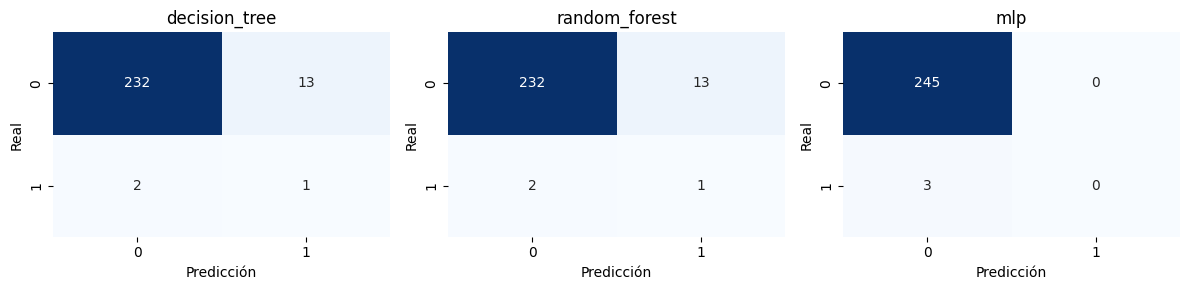

In [4]:
fig, axes = plt.subplots(1, len(tabla_metricas), figsize=(4 * len(tabla_metricas), 3))
if len(tabla_metricas) == 1:
    axes = [axes]
for ax, (_, fila) in zip(axes, tabla_metricas.iterrows()):
    sns.heatmap(fila['matriz_confusion'], annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(fila['modelo'])
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()


## Lectura responsable

La clase positiva tiene solo tres casos en la prueba. Las matrices y métricas describen este corte temporal; no prueban generalización, causalidad ni impacto pedagógico. La regla de resguardo de la interfaz se evalúa por separado.
